# 31회차 기출문제


## 문제 1

**Data description**

개인의 헬스케어 데이터를 활용하여 비만 수준을 예측하는 문제입니다.

-   **Gender** : 성별

-   **Age** : 나이

-   **Height** : 키

-   **Weight** : 몸무게

-   **family_history_with_overweight** : 가족 중 과체중인 사람이 있는지 여부

-   **FAVC** : 고칼로리 식품을 자주 섭취하는지 여부

-   **FCVC** : 채소 섭취 빈도

-   **NCP** : 식사 횟수

-   **CAEC** : 간식 섭취 빈도

-   **SMOKE** : 흡연 여부

-   **CH20** : 물 섭취 양

-   **SCC** : 섭취 칼로리를 모니터링하는지 여부

-   **FAF** : 운동 빈도

-   **TUE** : 전자제품(휴대폰, TV, 비디오게임 등) 사용 빈도

-   **CALC** : 알코올 섭취 빈도

-   **MTRANS** : 주로 이용하는 교통 수단

-   **NObeyesdad** : 비만 수준

    -   overweight_level_i : 과체중 수준 i
    -   obesity_type_i : 비만 유형 i
    -   obesity_type_ii : 비만 유형 ii
    -   obesity_type_iii : 비만 유형 iii

1.  **데이터 분포를 살펴보고 특성을 기술하시오.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings

warnings.filterwarnings('ignore')

d1 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/31/problem1.csv')
d1 = d1[d1.columns[1:]]
print(d1.info())
d1.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1262 non-null   object 
 1   Gender                          1262 non-null   object 
 2   Age                             1262 non-null   int64  
 3   Height                          1262 non-null   float64
 4   Weight                          1262 non-null   int64  
 5   family_history_with_overweight  1262 non-null   object 
 6   FAVC                            1262 non-null   object 
 7   FCVC                            1262 non-null   object 
 8   NCP                             1262 non-null   int64  
 9   CAEC                            1262 non-null   object 
 10  SMOKE                           1262 non-null   object 
 11  CH2O                            1262 non-null   object 
 12  SCC                             12

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,4,male,27,1.80,87,no,no,always,3,sometimes,no,between 1 and 2 l,no,2 to 4,0 to 2,frequently,walking,overweight_level_i,26.851852
1,11,male,26,1.85,105,yes,yes,always,3,frequently,no,more than 2 l,no,2 to 4,>5,sometimes,public_transportation,obesity_type_i,30.679328


1. 데이터 분포를 살펴보고 특성을 기술하시오.EDA & 결측치 및 이상치를 판단하고 설명하라

In [2]:
d1.isna().mean()[d1.isna().mean()>0]

SCC    0.002377
dtype: float64

scc 컬럼에 0.002377%의 결측치가 존재한다. 전체 데이터 대비 결측치가 극히 적으며, 전체 데이터 분포에 큰 영향을 미치지 않으므로  
삭제하는 것이 효율적이다. 

In [3]:
d1['id'].nunique()

1262

In [4]:
d1.drop(columns=['id'], inplace=True)
d1 = d1.dropna()

id 컬럼은 단순 식별자이므로 모델학습에 기여하지 않는다. 삭제한다. 

<<연속형 변수 통계량 및 시각화>>


,count,mean,std,min,25%,50%,75%,max
Age,1259.0,25.754567,9.908531,15.000000,21.000000,24.000000,27.000000,150.000000
Height,1259.0,1.708876,0.091233,1.450000,1.631439,1.710616,1.775582,1.980000
Weight,1259.0,101.023034,21.490752,53.000000,82.000000,105.000000,116.000000,173.000000
NCP,1259.0,2.664813,0.757869,1.000000,3.000000,3.000000,3.000000,4.000000
BMI,1259.0,34.431891,6.102283,22.826739,30.715939,34.343740,38.919026,50.811753


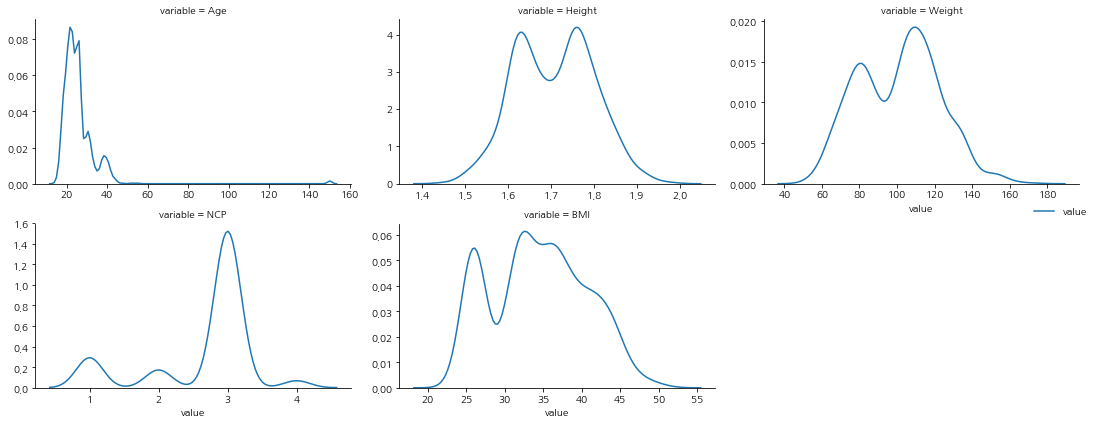

<<명목형 변수 통계량 및 시각화>>


,count,unique,top,freq
Gender,1259,2,male,634
family_history_with_overweight,1259,2,yes,1170
FAVC,1259,2,yes,1218
FCVC,1259,3,always,628
CAEC,1259,4,sometimes,1187
SMOKE,1259,2,no,1234
CH2O,1259,3,between 1 and 2 l,617
SCC,1259,2,no,1219
FAF,1259,4,1 to 2,480
TUE,1259,3,0 to 2,614


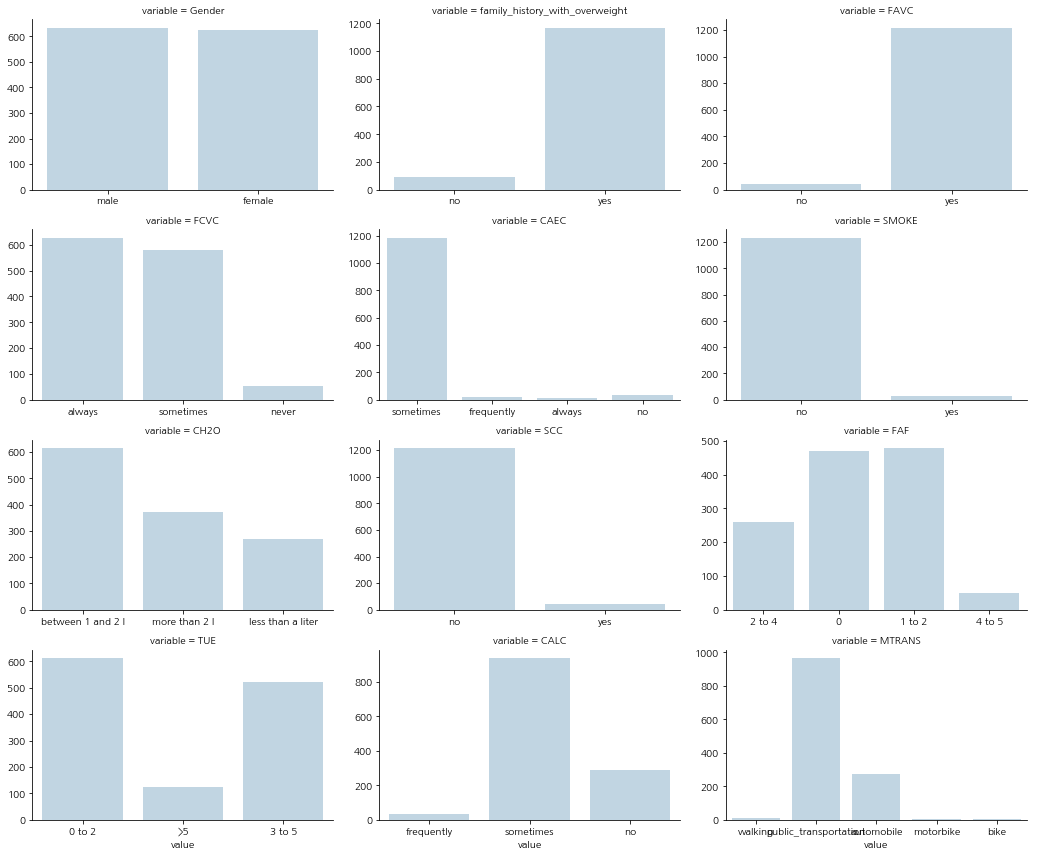

In [5]:
n_cols = d1.select_dtypes('number').columns
c_cols = d1.select_dtypes('O').columns[:-1]

print("<<연속형 변수 통계량 및 시각화>>")
display(d1[n_cols].describe().T)
mt = d1.melt(value_vars=n_cols)
g = sns.FacetGrid(mt, col='variable',  col_wrap=3, sharex=False, sharey=False, height=3, aspect=1.6)
g.map(sns.kdeplot, 'value')
g.add_legend()
plt.tight_layout()
plt.show()
print("<<명목형 변수 통계량 및 시각화>>")
display(d1[c_cols].describe().T)
mt = d1.melt(value_vars=c_cols)
g = sns.FacetGrid(mt, col='variable',  col_wrap=3, sharex=False, sharey=False, height=3, aspect=1.6)
g.map(sns.countplot, 'value', alpha=0.3)
g.add_legend()
plt.tight_layout()
plt.show()

- 양의 왜도(로그, boxcox 변환으로 분포 모양 완화 가능): age
- 쌍봉분포: Hight, weight, bmi
- 비만이력/FAVC(yes), SMOKE/scc(no) 불균형 데이터
- Tue 5이상 빈도가 낮음, 알코올 섭취빈도 자주 비율 아주 낮음|

In [6]:
#수치형 변수 이상치 탐지
er = d1[n_cols].describe().T
q1 = er['25%']
q3 = er['75%']
iqr = q3 - q1
up = q3 + (1.5*iqr)
down = q1 - (1.5*iqr)

for col in up.index:
    e = d1[(d1[col] > up[col]) | (d1[col] < down[col])]
    print(f"{col} 이상치 비율: {len(e)/len(d1)*100:.2f} %")

Age 이상치 비율: 9.29 %
Height 이상치 비율: 0.00 %
Weight 이상치 비율: 0.08 %
NCP 이상치 비율: 25.97 %
BMI 이상치 비율: 0.00 %


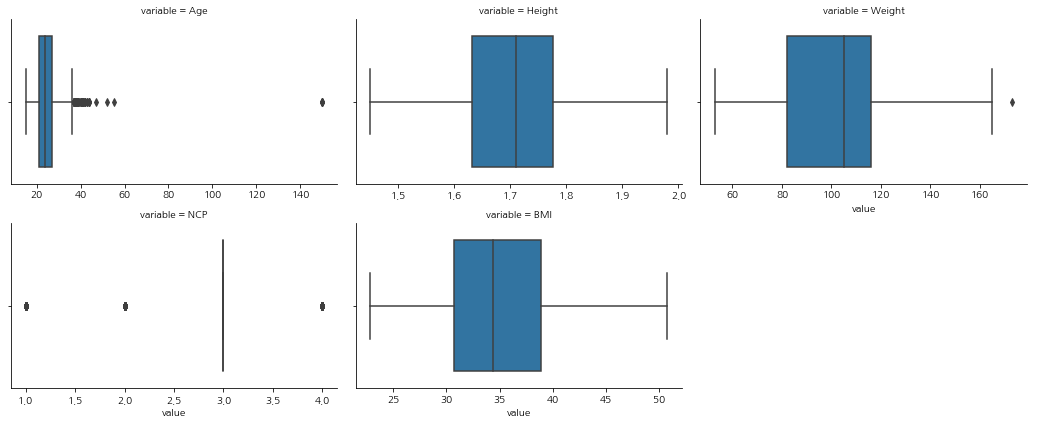

In [7]:
mt = d1.melt(value_vars=n_cols)
g = sns.FacetGrid(mt, col='variable', col_wrap=3, sharex=False, sharey=False, height=3, aspect=1.6)
g.map(sns.boxplot, 'value')
g.add_legend()
plt.tight_layout()
plt.show()

Age 컬럼에서 140세 이상의 이상치가 식별되므로 제거한다.(데이터 입력, 수집단계의 실수일 수 있음)  
이외의 컬럼 이상치 후보군은 데이터 지식이 없기 때문에 삭제하지 않는다.  
(실제로 이상치처럼 보이지만 특징정보로 활용될 수 있으므로)  

In [8]:
print(f"데이터 삭제 전: {len(d1)}")
d1 = d1[d1['Age'] <= 120]
print(f"데이터 삭제 후: {len(d1)}")

데이터 삭제 전: 1259
데이터 삭제 후: 1254


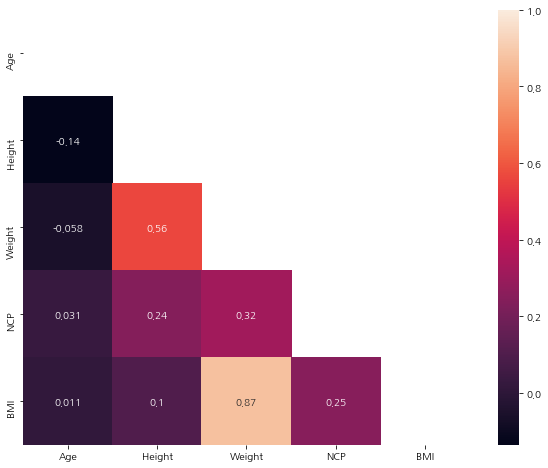

In [9]:
plt.figure(figsize=(10, 8))
corr = d1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

몸무게-bmi, 키-몸무게 간 양의 상관관계가 식별된다.    
비슷한 정보를 담고 있는 것으로 추측되며, 다중공선성 여부를 확인하기 위해 vif 계수를 확인한다.  
vif가 10 이상이면 다중공선성으로 판단한다. 

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = n_cols
vif['vif'] = [variance_inflation_factor(d1[n_cols].values, i) for i in range(len(n_cols))]
display(vif)

,name,vif
0,Age,18.785184
1,Height,54.784213
2,Weight,116.049571
3,NCP,15.007239
4,BMI,123.431775


모든 컬럼의 vif가 15~123사이로 강한 다중공선성이 있는 것이 식별되었다. 

2.  **데이터 전처리 기법 2가지를 기술하고, 해당 기법이 어떤 효과가 있는지 설명하시오.**

- 스케일링: 연속형 변수의 스케일을 정규분포(평균0, 분산1)를 가정하여 -1~1사이 값으로 맞추어, 모델의 학습 안정성과 정확도 향상   
  거리기반 방식인 knn, 선형회귀, svm 등의 모델에 필수적으로 사용
- 차원축소(여기서는 PCA): SVD 방식으로 분산설명력이 큰 순서대로 각 직교하는 주성분 축으로 차원을 축소시킴, 원 데이터의 분산설명력을  
  어느정도 보존한 상태에서 다중공선성이 제거됨.

3.  **주어진 데이터를 확인하고, 파생변수를 1개 생성하시오.** 

다중공선성이 가장 높은 설명변수를 카테고리화 한 후 해당변수만을 사용

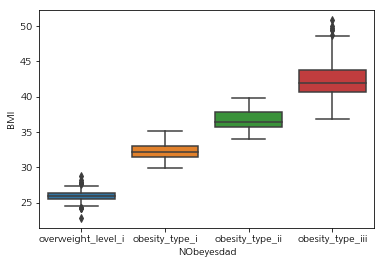

In [11]:
sns.boxplot(data=d1, x='NObeyesdad', y='BMI')
plt.show()

In [12]:
d1.groupby('NObeyesdad')['BMI'].describe()

,count,mean,std,min,25%,50%,75%,max
NObeyesdad,,,,,,,,
obesity_type_i,347.0,32.260083,1.126101,29.911958,31.402133,32.203812,32.973741,35.171095
obesity_type_ii,296.0,36.732270,1.283258,34.048509,35.753610,36.418410,37.884250,39.786652
obesity_type_iii,322.0,42.274572,2.552838,36.774400,40.607079,41.942617,43.837706,50.811753
overweight_level_i,289.0,25.988723,0.661045,22.826739,25.574891,25.971277,26.387981,28.769607


비만도별 BMI 통계량을 보면 과체중 1과 비만1은 완벽하게 분리가 되고, 나머지 구간은 일부가 겹치지만 대체로
분류가 가능한 수준인 것을 알 수 있다.

따라서 비만 1~3까지는 사분위수 기반 경계 평균(이전 구간 3분위수+다음구간 1분위수/2)값을 기준으로 분류구간을 정한다.

[34.3610765 39.249169 ]


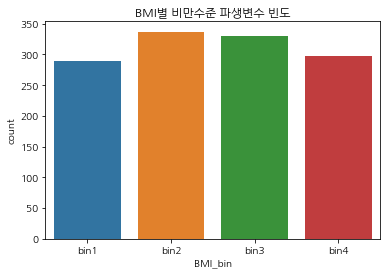

In [13]:
front = np.array([32.971628, 37.880693]) #이전구간 3분위수
back = np.array([35.750525, 40.617645]) #다음구간 1분위수

print((front+back)/2)

bins = [0, 29, 34.3610765, 39.249169, 51] #앞서 구한 카테고리 경계값

labels = ['bin1', 'bin2', 'bin3', 'bin4']
d1['BMI_bin'] = pd.cut(d1['BMI'], bins=bins, labels=labels).astype('O')

sns.countplot(d1['BMI_bin'] )
plt.title('BMI별 비만수준 파생변수 빈도')
plt.show()

4.  **앙상블을 제외한 분류 알고리즘 3개를 선정하고, 그 이유를 기술하시오.**


1. 의사결정나무: 트리기반 모델로 불순도를 기준으로 트리를 분할하므로 이상치나 결측치에 강건하여 스케일링 불필요,  
    해석이 쉬우며, 학습 이후 feature importance로 변수 중요도 확인 및 시각화 가능
2. mlp: 인공신경망 모델로 활성화 함수를 활용하여 비선형 특징 또한 포착해 낼 수 있으며, 데이터가 충분하다면 높은 성능을 보여줌   
   (하이퍼파라미터 튜닝 필요)
3. svm : 결정경계와 서포트벡터를 활용한 비확률적 선형 분류모델로 데이터의 특성이 적어도 비교적 뛰어난 성능을 보여줌(저/고차원 가능)  
   다만, 거리기반 모델로 스케일링이 필요하며 매개변수 최적화가 까다로움

5.  **하이퍼파라미터 튜닝을 실시하고, Precision, Recall을 계산하시오.**

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score

x = d1.drop(columns=['BMI', 'NObeyesdad'])
y = d1['NObeyesdad']

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42)

n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

ps = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.8))]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

dt = Pipeline([
    ('processor', ps), 
    ('cl', DecisionTreeClassifier(random_state=42))
])

svc = Pipeline([
    ('processor', ps), 
    ('cl', SVC(random_state=42, probability=True))
])

mlp = Pipeline([
    ('processor', ps), 
    ('cl', MLPClassifier(random_state=42))
])

p1 = {'cl__max_depth': [3, 5], 'cl__ccp_alpha': [0.001, 10, 100]}
p2 = {'cl__C': [1, 10, 100], 'cl__kernel': ['rbf', 'sigmoid']}
p3 = {'cl__max_iter': [100, 1000], 'cl__learning_rate_init': [0.001, 0.01, 0.1]}

dt_g = GridSearchCV(
    estimator = dt,
    param_grid=p1, 
    scoring = 'recall_macro', 
    cv = 5)


svm_g = GridSearchCV(
    estimator = svc,
    param_grid=p2, 
    scoring = 'recall_macro', 
    cv = 5)


mlp_g = GridSearchCV(
    estimator = mlp,
    param_grid=p3, 
    scoring = 'recall_macro', 
    cv = 5)

model_list = [('의사결정나무', dt_g), ('svm classifier', svm_g), ('mlp_g', mlp_g)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'precision', 'recall'])

for n1, model in model_list:
    model.fit(train_x, train_y)
    print(f"{n1} 모델 최적의 파라미터: {model.best_params_} / score: {model.best_score_}")
    for n2, x, y in d_list:
        pred = model.predict(x)
        precision = precision_score(y, pred, average='macro')
        recall = recall_score(y, pred, average='macro')
        rs.loc[len(rs)] = [n1, n2, precision, recall]
display(rs)

의사결정나무 모델 최적의 파라미터: {'cl__ccp_alpha': 0.001, 'cl__max_depth': 5} / score: 0.9907845835836648
svm classifier 모델 최적의 파라미터: {'cl__C': 10, 'cl__kernel': 'rbf'} / score: 0.990804191426802
mlp_g 모델 최적의 파라미터: {'cl__learning_rate_init': 0.001, 'cl__max_iter': 100} / score: 0.9898245995900673


,model,data,precision,recall
0,의사결정나무,train,0.996822,0.997024
1,의사결정나무,test,0.975149,0.978906
2,svm classifier,train,0.999012,0.998927
3,svm classifier,test,0.997396,0.996032
4,mlp_g,train,0.994759,0.994959
5,mlp_g,test,0.989528,0.990769


그리드 서치를 통해 하이퍼파라미터 튜닝을 실시하였다.  
- 의사결정나무 모델 최적의 파라미터: {'ccp_alpha': 0.001, 'max_depth': 5} / score: 0.9907845835836648
- svm classifier 모델 최적의 파라미터: {'C': 10, 'kernel': 'rbf'} / score: 0.990804191426802
- mlp_g 모델 최적의 파라미터: {'learning_rate': 0.001, 'max_iter': 100} / score: 0.9898245995900673


세 모델 모두 과적합이 식별되지 않았으며, 정밀도와 재현율 모두 높은 성능을 보여주고 있다.  
test set 기준 정밀도, 재현율은 svm classifier가 높았다.

해당 문제는 실제 비만인 사람을 최대한 많이 찾아내는 것을 목적으로 재현율을 최대화하는 것을 목표로 한다고 하면   
(헬스케어 프로그램 홍보를 위해) 재현율이 높은 모델을 선택하는 것이 더욱 적합하다. 

6.  **위의 결과에 대해서 SOFT VOTING 기법을 적용하고 이전 결과와 비교하시오.**

In [15]:
from sklearn.ensemble import VotingClassifier

sv = VotingClassifier(
    estimators = [
        ('dt', dt_g), 
        ('svc', svm_g), 
        ('mlp', mlp_g)],
    voting='soft')

sv.fit(train_x, train_y)
for n2, x, y in d_list:
    pred = sv.predict(x)
    precision = precision_score(y, pred, average='macro')
    recall = recall_score(y, pred, average='macro')
    rs.loc[len(rs)] = ['soft voting', n2, precision, recall]
display(rs)

,model,data,precision,recall
0,의사결정나무,train,0.996822,0.997024
1,의사결정나무,test,0.975149,0.978906
2,svm classifier,train,0.999012,0.998927
3,svm classifier,test,0.997396,0.996032
4,mlp_g,train,0.994759,0.994959
5,mlp_g,test,0.989528,0.990769
6,soft voting,train,0.996867,0.996943
7,soft voting,test,0.989528,0.990769


가장 성능이 떨어지는 의사결정나무보다는 높은 성능, 나머지 두 개 모델보다는 낮은 성능을 보여주고 있다.  

세 모델을 앙상블하여 일반화 성능을 보여주고 있으나, mlp 모델을 선택하는 것이 더 적절할 것이다. .

7.  **하나의 모델을 선정하여 Feature importance와 Drop column importance를 활용하여 변수를 선택하시오.**

| 항목         | Drop Column Importance     | Permutation Importance          |
| ---------- | -------------------------- | ------------------------------- |
| **방법**     | 변수를 **아예 제거**한 후 모델을 다시 학습 | 변수 값을 **무작위로 섞어** 성능 변화를 측정     |
| **학습**     | 변수 제거 후 **다시 학습**          | 기존 모델 그대로, 테스트셋에서만 **예측 변화 측정** |
| **비용(시간)** | 느림 (모델 N번 재학습)             | 빠름 (한 번 학습한 모델로 평가만 반복)         |
| **해석**     | 해당 변수가 모델 학습에 얼마나 중요했는지    | 해당 변수가 예측에 얼마나 기여했는지            |
| **영향력 평가** | 학습 과정에서의 중요도 반영            | 예측 단계에서의 중요도만 반영                |
| **과적합 영향** | 적음 (매번 학습하므로 일반화 반영)       | 높을 수 있음 (기존 모델 그대로 사용)          |


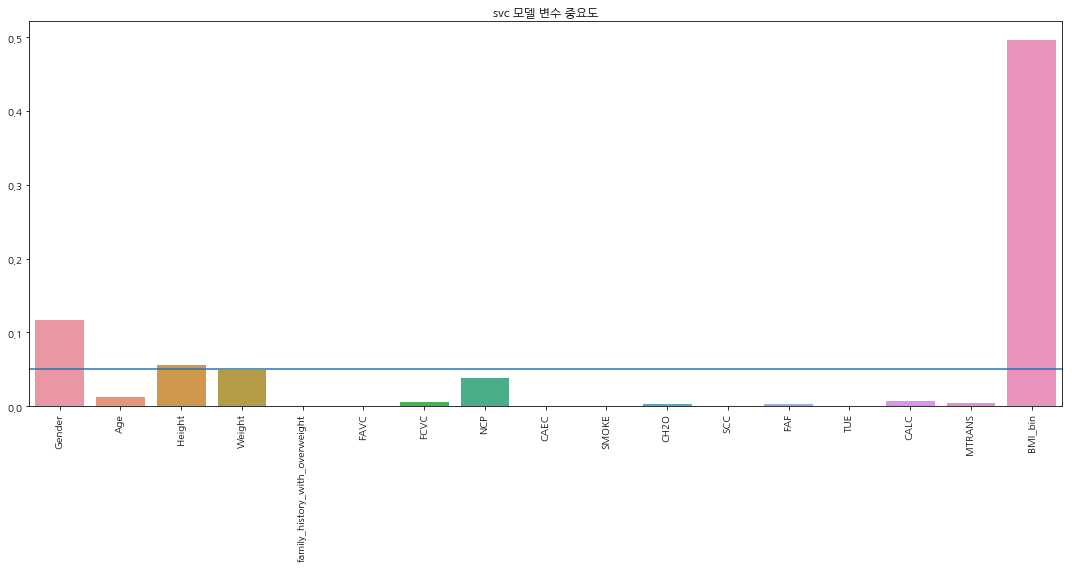

In [16]:
# 최적의 모델인 MLP를 활용하여 permutation importance 방식으로 변수 선택(피처 imp는 미제공됨)

from sklearn.inspection import permutation_importance

pm =  permutation_importance(svm_g, test_x, test_y, n_repeats=10, random_state=42)

imp = pm.importances_mean

plt.figure(figsize=(15, 8))
sns.barplot(x=train_x.columns, y=imp)
plt.title('svc 모델 변수 중요도')
plt.axhline(y=0.05)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

예측 단계에서 모델의 영향력 기여율이 5% 이상인 4개 변수(BMI_bins. Gender, Height, Weight)를 선택한다.

In [17]:
full_score = svm_g.best_estimator_.score(train_x, train_y)

rs = pd.DataFrame(columns=['drop_col', 'diff'])

for col in train_x.columns:
    tmp_x = train_x.drop(columns=[col])
    n_cols = tmp_x.select_dtypes('number').columns
    c_cols = tmp_x.select_dtypes('O').columns

    ps = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.8))]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough')
        
    svc = Pipeline([
    ('processor', ps), 
    ('cl', SVC(random_state=42, probability=True, C=10, kernel='rbf'))])
    
    svc.fit(tmp_x, train_y)
        
    drop_col_imp = full_score - svc.score(tmp_x, train_y) 
    
    rs.loc[len(rs)] = [col, drop_col_imp]

display(rs.sort_values(by='diff', ascending=False))

,drop_col,diff
16,BMI_bin,0.019149
3,Weight,0.003191
14,CALC,0.002128
6,FCVC,0.002128
1,Age,0.002128
7,NCP,0.001064
12,FAF,0.001064
11,SCC,0.000000
15,MTRANS,0.000000
13,TUE,0.000000


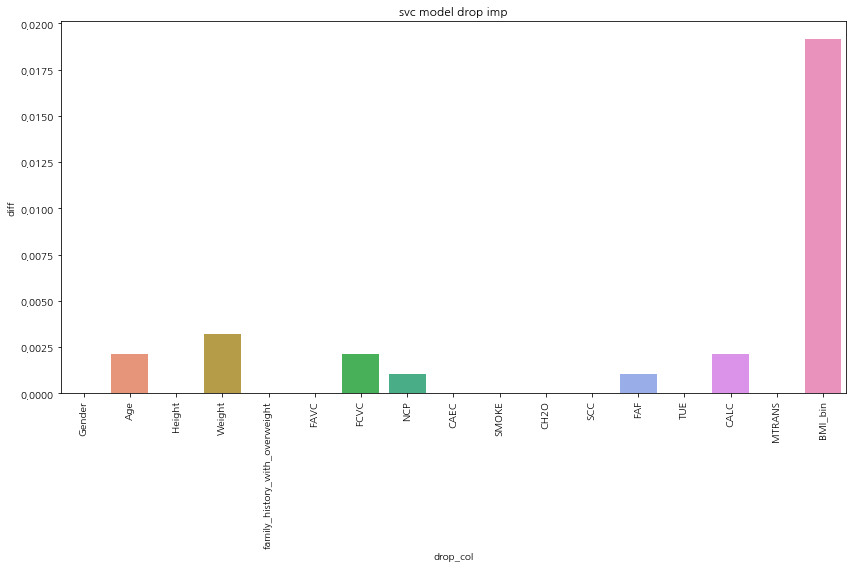

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(data = rs, x='drop_col', y='diff')
plt.title('svc model drop imp')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Drop column importance 결과, BMI_bin가 가장 중요한 변수이며, Weight,CALC, FCVC, Age순으로 중요함을 알 수 있다.  
Gender 등 다수 변수는 모델 성능에 아무런 영향을 미치지 않는다. 

## 문제 2

**Data description**

개인의 건강검진 데이터를 활용하여 다음 문제를 해결하시오.

-   **ID**

-   **키**

-   **weight**

-   **생년월일**

-   **건강검진일**

-   **공학여부**

-   **채소섭취정도**

-   **아침식사여부**

-   **일주일운동시간**

-   **수면시간**

-   **성별**

1.  **위 표를 바탕으로 파생변수(적정체중 여부)를 도출하고, 만나이와 파생변수(적정체중 여부)의 빈도표를 산출하시오.**

-   만나이 : (검진날짜 - 생년월일)/365, 소수점 버림

-   BMI : $\frac{몸무게}{키^2}$ (키는 m 기준), 소수점 둘째자리 반올림

|    -  | 16세         | 17세         |
|------|--------------|--------------|
| 남자 | 17.3 \~ 18.4 | 17.8 \~ 20.4 |
| 여자 | 16.7 \~ 18.7 | 16.7 \~ 18.7 |

: 성별과 만나이에 따른 BMI 기준표(적정 체중 기준)

|    -  | YES | NO  |
|------|-----|-----|
| 16세 | 00  | 00  |
| 17세 | 00  | 00  |

: 빈도표 예시

In [19]:
d2 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/31/problem2.csv')

d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6801 entries, 0 to 6800
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       6801 non-null   object 
 1   키        6801 non-null   float64
 2   weight   6801 non-null   float64
 3   생년월일     6801 non-null   int64  
 4   건강검진일    6801 non-null   object 
 5   공학여부     6801 non-null   int64  
 6   채소섭취정도   6801 non-null   int64  
 7   아침식사여부   6801 non-null   int64  
 8   일주일운동시간  6801 non-null   float64
 9   수면시간     6801 non-null   float64
 10  성별       6801 non-null   object 
dtypes: float64(4), int64(4), object(3)
memory usage: 584.6+ KB


In [20]:
d2.head()

,ID,키,weight,생년월일,건강검진일,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별
0,ID_4135,169.01,65.47,20041003,2020_11_15,1,2,1,4.4,8.3,남성
1,ID_3289,181.62,69.36,19970725,2014_11_20,0,3,0,4.4,6.9,남성
2,ID_1847,160.89,65.12,20020921,2020_01_28,1,1,1,1.7,9.6,여성
3,ID_4785,162.21,62.28,20020106,2018_09_27,1,4,0,5.1,6.8,남성
4,ID_5693,159.13,54.11,19980708,2015_03_03,0,4,1,0.3,8.5,여성


In [21]:
d2[['공학여부', '채소섭취정도', '아침식사여부']] = d2[['공학여부', '채소섭취정도', '아침식사여부']].astype('O')

In [22]:
d2['생년월일'] = pd.to_datetime(d2['생년월일'], format='%Y%m%d')
d2['건강검진일'] = pd.to_datetime(d2['건강검진일'], format='%Y_%m_%d')
d2['만나이'] = ((d2['건강검진일'] - d2['생년월일']).dt.days/365).astype('int64')

d2['BMI'] = (d2['weight']/(d2['키']/100)**2).round(1)

d2.head()

,ID,키,weight,생년월일,건강검진일,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별,만나이,BMI
0,ID_4135,169.01,65.47,2004-10-03,2020-11-15,1,2,1,4.4,8.3,남성,16,22.9
1,ID_3289,181.62,69.36,1997-07-25,2014-11-20,0,3,0,4.4,6.9,남성,17,21.0
2,ID_1847,160.89,65.12,2002-09-21,2020-01-28,1,1,1,1.7,9.6,여성,17,25.2
3,ID_4785,162.21,62.28,2002-01-06,2018-09-27,1,4,0,5.1,6.8,남성,16,23.7
4,ID_5693,159.13,54.11,1998-07-08,2015-03-03,0,4,1,0.3,8.5,여성,16,21.4


In [23]:
cond1 = (d2['성별'] == '남성') & (d2['만나이'] == 16) & (d2['BMI'].between(17.3, 18.4))
cond2 = (d2['성별'] == '남성') & (d2['만나이'] == 17) & (d2['BMI'].between(17.8, 20.4))
cond3 = (d2['성별'] == '여성') & (d2['만나이'] == 16) & (d2['BMI'].between(16.7, 18.7))
cond4 = (d2['성별'] == '여성') & (d2['만나이'] == 17) & (d2['BMI'].between(16.7, 18.7))


d2['적정체중'] = np.where(cond1|cond2|cond3|cond4, 'Yes', 'No')

cr = pd.crosstab(d2['만나이'], d2['적정체중'])

display(cr)

적정체중,No,Yes
만나이,,
16,2981,134
17,3343,343


2.  **파생변수(적정체중 여부)와 기존 변수와의 유의성 확인하시오.**



파생변수는 이진 명목형 변수이며  
기존변수의 타입에 따라 다음과 같이 검정한다. (유의수준 5%)

- 연속형 변수: 정규성을 만족하면 독립검정 ttest, 만족하지 않으면 맨휘트니 u 검정(비모수검정)
- 명목형 변수: 비모수 검정인 카이제곱 독립성 검정

- 귀무가설: 파생변수와 독립변수 간 독립이다.(유의성이 없음)
- 대립가설: 파생변수와 독립변수 간 통계적 유의성이 있다. 

In [24]:
d2.drop(columns=['ID', '생년월일', '건강검진일'], inplace=True)

In [25]:
from scipy.stats import shapiro, mannwhitneyu

n_cols = d2.select_dtypes('number').columns
c_cols = d2.select_dtypes('O').columns[:-1]

rs = []
# 연속형 변수와의 유의성 확인: 정규성 만족한다면 독립검정 ttest
for col in n_cols:
    gr = [(name, g[col]) for name, g in d2.groupby("적정체중")]
    for name, g in gr:
        stat, p = shapiro(g)
        print(f" = {col}-{name} 정규성 검정결과({p:.3f}): 정규성 ", "만족" if p >=0.05 else "불만족")
print('-'*50)
for col in n_cols:
    gr = [(name, g[col]) for name, g in d2.groupby("적정체중")]
    stat, p = mannwhitneyu(gr[0][1], gr[1][1])
    if p < 0.05:
        rs.append(col)
    print(f"- {col} 맨휘트니 u 검정결과({p:.3f}): 통계적 유의(연관) ", "만족" if p < 0.05 else "불만족")

 = 키-No 정규성 검정결과(0.000): 정규성  불만족
 = 키-Yes 정규성 검정결과(0.000): 정규성  불만족
 = weight-No 정규성 검정결과(0.000): 정규성  불만족
 = weight-Yes 정규성 검정결과(0.000): 정규성  불만족
 = 일주일운동시간-No 정규성 검정결과(0.000): 정규성  불만족
 = 일주일운동시간-Yes 정규성 검정결과(0.000): 정규성  불만족
 = 수면시간-No 정규성 검정결과(0.000): 정규성  불만족
 = 수면시간-Yes 정규성 검정결과(0.000): 정규성  불만족
 = 만나이-No 정규성 검정결과(0.000): 정규성  불만족
 = 만나이-Yes 정규성 검정결과(0.000): 정규성  불만족
 = BMI-No 정규성 검정결과(0.000): 정규성  불만족
 = BMI-Yes 정규성 검정결과(0.000): 정규성  불만족
--------------------------------------------------
- 키 맨휘트니 u 검정결과(0.000): 통계적 유의(연관)  만족
- weight 맨휘트니 u 검정결과(0.000): 통계적 유의(연관)  만족
- 일주일운동시간 맨휘트니 u 검정결과(0.838): 통계적 유의(연관)  불만족
- 수면시간 맨휘트니 u 검정결과(0.722): 통계적 유의(연관)  불만족
- 만나이 맨휘트니 u 검정결과(0.000): 통계적 유의(연관)  만족
- BMI 맨휘트니 u 검정결과(0.000): 통계적 유의(연관)  만족


In [26]:
from scipy.stats import chi2_contingency

for col in c_cols:
    cr = pd.crosstab(d2[col], d2['적정체중'])
    stat, p, ddof, expected = chi2_contingency(cr)
    if p < 0.05:
        rs.append(col)
    print(f"-{col} 카이제곱 독립성 검정결과({p:.3f}): 통계적 유의(연관)", "만족" if p < 0.05 else "불만족")

-공학여부 카이제곱 독립성 검정결과(0.154): 통계적 유의(연관) 불만족
-채소섭취정도 카이제곱 독립성 검정결과(0.531): 통계적 유의(연관) 불만족
-아침식사여부 카이제곱 독립성 검정결과(0.432): 통계적 유의(연관) 불만족
-성별 카이제곱 독립성 검정결과(0.714): 통계적 유의(연관) 불만족


In [27]:
rs

['키', 'weight', '만나이', 'BMI']

'키', 'weight', '만나이', 'BMI'' 변수가 유의수준 5% 하에서 귀무가설을 기각하여 통계적 유의성이 있다.  
이는 해당 변수들이 종속변수를 예측하는 특징이 있음을 의미한다.

3.  **Logistic regression과 XGBoost 모형을 적합하시오.**

    **(위 문제에서 통계적으로 유의한 변수를 활용하여) 구문 제거 –\> 문제 수정**

In [28]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

x = d2.drop(columns=['적정체중'])
y = np.where(d2['적정체중'] == 'Yes', 1, 0)

x = pd.get_dummies(x, columns=x.select_dtypes('O').columns, drop_first=True)

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42)

sc = StandardScaler()

train_x2 = pd.DataFrame(sc.fit_transform(train_x), columns=x.columns)

#모델
lg = sm.Logit(train_y, sm.add_constant(train_x2)).fit()
xgb = XGBClassifier(random_state=42).fit(train_x, train_y)

m_list = [('로지스틱회귀', lg), ('xgb classifier', xgb)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'precision', 'recall', 'f1'])

for n1, model in m_list:
    for n2, x, y in d_list:
        if n1 == '로지스틱회귀':
            x = pd.DataFrame(sc.transform(x), columns=train_x.columns)
            x = sm.add_constant(x)
            proba = model.predict(x)
            pred = np.where(proba >= 0.5, 1, 0)
        else:
            pred = model.predict(x)
        precision = precision_score(y, pred, average='macro')
        recall = recall_score(y, pred, average='macro')
        f1 = f1_score(y, pred, average='macro')
        rs.loc[len(rs)] = [n1, n2, precision, recall, f1]
display(rs)

Optimization terminated successfully.
         Current function value: 0.064477
         Iterations 11


,model,data,precision,recall,f1
0,로지스틱회귀,train,0.922990,0.882232,0.901388
1,로지스틱회귀,test,0.912508,0.876980,0.893794
2,xgb classifier,train,0.997222,0.999789,0.998502
3,xgb classifier,test,0.991736,0.999368,0.995517


두 모델 모두 과적합 없이 준수한 성능을 보여주었으나, XGB 분류모델의 정밀도, 재현율, 조화평균이 0.99 이상으로 매우  
뛰어난 성능을 보여주었으므로 해당 모델을 선택한다.  

정밀도(0.991736), 재현율(0.999368), 조화평균(0.995517)

4.  **회귀계수에 대해 오즈비로 해석하고, 통계적 유의성을 확인하시오.**

In [29]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 5100
Model:                          Logit   Df Residuals:                     5086
Method:                           MLE   Df Model:                           13
Date:                Sun, 28 Sep 2025   Pseudo R-squ.:                  0.7463
Time:                        01:41:42   Log-Likelihood:                -328.83
converged:                       True   LL-Null:                       -1296.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.3003      0.559    -18.429      0.000     -11.396      -9.205
키             -9.7203      1.676     -5.799      0.000     -13.006      -6.435
weight        12.7950      2.209      5.793      0.0

In [30]:
(np.exp(lg.params[lg.pvalues>0.05])-1)*100

일주일운동시간     13.502320
수면시간         8.921379
공학여부_1      -7.383959
채소섭취정도_1    19.080310
채소섭취정도_2    13.024083
채소섭취정도_3    22.960753
채소섭취정도_4    10.373818
아침식사여부_1    13.947201
dtype: float64

로지스틱 회귀 모형의 우도비(LLR p-value) 검정 p-value가 0.000로 유의수준 5% 하에서 통계적으로 유의한 모델이다.  
(적어도 하나의 설명변수의 회귀계수는 0이 아니다.)  

다음으로 각 설명변수의 pvalue가 0.05 이상인 것을 확인 후 해당 변수를 대상으로 오즈비 해석을 한다.  

- 일주일운동시간: 1시간 늘 때마다 정적체중이 될 오즈가 13.5% 증가
- 수면시간: 1시간 늘 때마다 적정체중 될 오즈가 8.92% 증가
- 공학여부_1 : 공학이 아닌 경우에 비해 적정체중 될 오즈가 7.39% 감소
- 채소섭취정도_1: 채소섭취정도 0에 비해 적정체중 될 오즈가 19.080310 % 증가
- 채소섭취정도_2: 채소섭취정도 0에 비해 적정체중 될 오즈가 13.024083 % 증가
- 채소섭취정도_3: 채소섭취정도 0에 비해 적정체중 될 오즈가 22.960753% 증가
- 채소섭취정도_4: 채소섭취정도 0에 비해 적정체중 될 오즈가 10.373818 % 증가
- 아침식사여부_1: 아침식사를 안 하는 경우에 비해 적정체중이 될 오즈가 13.947201% 증가

5.  **두 모형의 ROC curve를 시각화하시오(겹쳐그릴 것).**

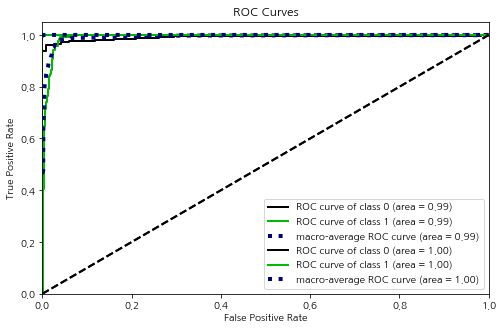

In [31]:
from scikitplot.metrics import plot_roc

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

#로지스틱
test_x2 = sc.transform(test_x)
test_x2 = sm.add_constant(test_x2)
proba = lg.predict(test_x2)
proba_array = np.vstack([1 - proba, proba]).T
plot_roc(test_y, proba_array, plot_micro=False, ax=ax)

#xgb
proba2 = xgb.predict_proba(test_x)
plot_roc(test_y, proba2, plot_micro=False, ax=ax)
plt.show()

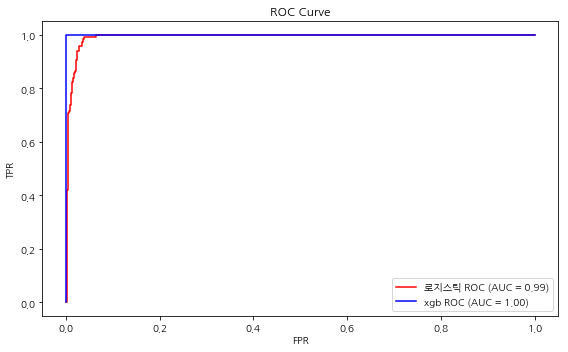

In [32]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

#로지스틱
test_x2 = sc.transform(test_x)
test_x2 = sm.add_constant(test_x2)
proba = lg.predict(test_x2)
#xgb
proba2 = xgb.predict_proba(test_x)[:, 1]

p_list = [('로지스틱', proba, 'r'), ('xgb', proba2, 'b')]

for name, prob, c in p_list:
    fpr, tpr, th = roc_curve(test_y, prob)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color=c, label=f"{name} ROC (AUC = {roc_auc:.2f})")
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC Curve')
    ax.legend()
    plt.tight_layout()
plt.show()

ROC 커브 결과 XGBoost 분류모델의 AUC(ROC 커브 아래 면적)가 1로 완벽하게 데이터를 예측함을 알 수 있다. 

## 문제 3


**평균이 (**$\theta$**)이고 분산이 100인 정규분포 (**$\mathcal{N}(\theta, 100)$**)에서 사전분포로 평균이 100, 분산이 256인 정규분포 (**$\mathcal{N}(100, 256)$**)를 사용합니다. 이때, 관측된 데이터 (**$x = 120$**)일 경우 사후분포의 평균을 구하시오.**

베이즈 추론 문제로, 사후분포는 사전분포와 데이터를 통해 얻어진 우도함수를 결합하여 다음과 같이 구할 수 있다.   
- 사전분포가 특정한 분포에 속할 때, 우도함수와 결합된 사후분포도 동일한 분포에 속함

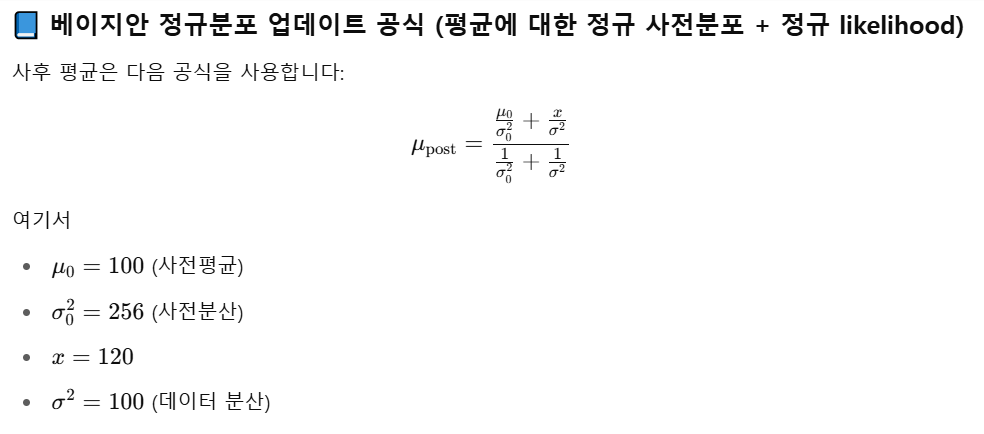

In [33]:
rm = 100 #사전분포
rv = 256 #사전분산
x = 120 #관측된 데이터
v = 100 #주어진 분산


p_m = (rm/rv+x/v)/(1/rv+1/v)

print(f"사후평균: {p_m}")

사후평균: 114.3820224719101


## 문제 4

**Data description**

-   **TV_Ad_Budget** : TV 광고 예산

-   **Radio_Ad_Budget** : 라디오 광고 예산

-   **Newspaper_Ad_Budget** : 신문 광고 예산

-   **Sales** : 판매 수익

1.  **선형 회귀 모델을 적합한 후 통계적 유의성을 검토하시오.**

In [34]:
d4 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/31/problem4.csv')

In [35]:
d4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TV_Ad_Budget         200 non-null    float64
 1   Radio_Ad_Budget      200 non-null    float64
 2   Newspaper_Ad_Budget  200 non-null    float64
 3   Sales                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [36]:
import statsmodels.formula.api as smf

model = smf.ols('Sales~TV_Ad_Budget+Radio_Ad_Budget+Newspaper_Ad_Budget', data=d4).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sun, 28 Sep 2025   Prob (F-statistic):           1.58e-96
Time:                        01:41:43   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.9389    

유의수준 5% 하   

- 귀무가설: 모델은 통계적으로 유의하지 않다.(모든 회귀계수는 0이다.)
- 대립가설: 모델이 통계적으로 유의하다.(적어도 하나의 회귀계수는 0이 아니다.)

모델의 F통계량이 1.58e-96로 0.05보다 작으므로 모델은 통계적으로 유의하다.     
하지만 잔차검정 결과, 선형성과 정규성을 만족하지 않으므로 모델의 신뢰성은 떨어진다고 할 수 있다. 


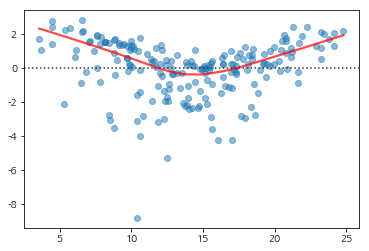

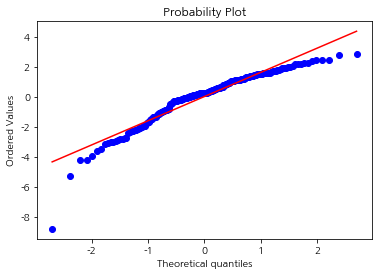

shapiro 정규성 검정결과: 0.000
het_breuschpagan 등분산성 검정결과: 0.162
더빈왓슨 검정결과: 2.084


In [37]:
from scipy.stats import shapiro, probplot
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

resid = model.resid
fitted = model.fittedvalues

sns.residplot(fitted, resid, lowess=True, scatter_kws={'alpha':0.5}, line_kws={'color':'r', 'alpha':0.7})
plt.show()
probplot(resid, fit=True, dist='norm', plot=plt)
plt.show()

s, p = shapiro(resid)
print(f"shapiro 정규성 검정결과: {p:.3f}")
s, p, _, _ = het_breuschpagan(resid, model.model.exog)
print(f"het_breuschpagan 등분산성 검정결과: {p:.3f}")
dw = durbin_watson(resid)
print(f"더빈왓슨 검정결과: {dw:.3f}")

2.  **변수 선택시에 먼저 제거가 될 변수를 파악하고, 근거를 제시하시오.**

모델이 잔차가정을 만족한다고 가정한다면, 각 설명변수의 회귀계수의 통계적 유의성을 확인해야 한다.  
유의수준 5% 하의 t 검정 pvalue를 통해 확인한다.  

- 귀무가설: 해당 변수의 회귀계수는 통계적으로 유의하지 않다.(0이다.)  
- 대립가설: 해당 변수의 회귀계수는 통계적으로 유의하다. 


Newspaper_Ad_Budget의 pvalue 가 0.860으로 귀무가설을 기각할 수 없기 때문에 해당 변수를 삭제하는 것을 고려한다. 

In [38]:
model2 = smf.ols('Sales~TV_Ad_Budget+Radio_Ad_Budget', data=d4).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Sun, 28 Sep 2025   Prob (F-statistic):           4.83e-98
Time:                        01:41:43   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.9211      0.294     

-   **분산팽창계수(VIF)를 활용하여 다중공선성을 진단하시오.**

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = model2.model.exog_names
vif['vif'] = [variance_inflation_factor(model2.model.exog, i) for i in range(len(model2.model.exog_names))]

display(vif[1:])

,name,vif
1,TV_Ad_Budget,1.003013
2,Radio_Ad_Budget,1.003013


두 변수 모두 vif가 1에 가까우므로 다중공선성이 존재하지 않는다.

## 문제 5

회사에서는 3개의 다른 마케팅 캠페인(캠페인 A, 캠페인 B, 캠페인 C)을 실행하여 고객에게 이메일을 발송했습니다. 각 캠페인 후, 고객이 제품을 구매했는지 여부를 기록했습니다. 다음 데이터는 15명의 고객에 대해 각 캠페인에 대한 구매 여부(1: 구매, 0: 미구매)를 나타낸 것입니다.

하나의 객체에 대해 3가지 조건으로 반복측정 하였으며, 각 결과값이 이진이므로 코크란 q 검정 문제이다.(비모수검정)

In [40]:
d5 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/31/problem5.csv')
d5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Customer    15 non-null     object
 1   Campaign_A  15 non-null     int64 
 2   Campaign_B  15 non-null     int64 
 3   Campaign_C  15 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 608.0+ bytes


In [41]:
d5 = d5.set_index('Customer', drop=True)
d5.head(3)

,Campaign_A,Campaign_B,Campaign_C
Customer,,,
Customer 1,1,0,0
Customer 2,0,1,1
Customer 3,1,1,0


유의수준 5% 하에서 다음과 같이 가설 수립 후 검정을 실시한다.  
- 귀무가설: 각 캠페인의 평균 구매수는 같다. 
- 대립가설: 적어도 한 캠페인의 평균 구매수는 다르다. 

In [42]:
from statsmodels.stats.contingency_tables import cochrans_q

rs = cochrans_q(d5.values)

print(f"코크란 Q 검정 통계량: {rs.statistic:.3f} / pvalue: {rs.pvalue:.3f}")

코크란 Q 검정 통계량: 0.182 / pvalue: 0.913


pvalue 0.913로 귀무가설을 기각할 수 없으므로, 세 캠페인의 평균 구매수는 같으며, 구매효과는 동일하다. 

## 문제 6

별도의 데이터 없음

어떤 웹사이트는 매시간 평균 4명의 방문자가 들어옵니다. 이 웹사이트에 대해 다음 질문에 답하시오.


$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$
:::

1.  **한 시간 동안 방문자가 한 명도 없을 확률을 계산하시오.**

$$
P(X = 0) = \frac{4^0 e^{-4}}{0!} = e^{-4} = 0.0183
$$

In [43]:
from scipy.stats import poisson

lam = 4 #단위시간 당 이벤트수

a1 = poisson.pmf(0, lam)
print(f"한 시간 동안 방문자가 한 명도 없을 확률: {a1:.4f}")

한 시간 동안 방문자가 한 명도 없을 확률: 0.0183


2.  **한 시간 동안 방문자가 5명 이상일 확률을 계산하시오.**

$$
\begin{aligned}
&P(X < 5) = P(X = 0) + P(X = 1) + P(X = 2) + P(X = 3) + P(X = 4) = 0.6289 \\
&P(X \geq 5) = 1 - P(X < 5) = 0.3711
\end{aligned}
$$

In [44]:
a2 = 1- poisson.cdf(4, lam)
print(f"한 시간 동안 방문자가 5명 이상일 확률: {a2:.4f}")

한 시간 동안 방문자가 5명 이상일 확률: 0.3712
